In [4]:
import pandas as pd

test_df = pd.read_csv("D:/projects/fake jd/data/processed/cross_platform_postings.csv")

print(test_df.shape)
print(test_df.head())
print(test_df["Label"].value_counts())

(115, 18)
   ID         Platform        Account Handle  \
0   1        Instagram     careerhub_india24   
1   2         Facebook  workfromhome_updates   
2   3         Telegram      quickjob_connect   
3   4  WhatsApp Groups       hirefast_remote   
4   5         LinkedIn         jobdesk_daily   

                             Job Title  Company (as advertised)  \
0  Work From Home Data Entry Executive    Amazon (impersonated)   
1        Online Form Filling Executive  Flipkart (impersonated)   
2           Customer Support Associate    Meesho (impersonated)   
3                Back Office Executive      Tata (impersonated)   
4        Online Verification Executive  Reliance (impersonated)   

        Work Mode                                      Shifts Listed  \
0  Work From Home  Part-time: 4 hours/day; Full-time: 8-9 hours/d...   
1  Work From Home  Morning 7AM-11AM; Evening 5PM-9PM; Night 10PM-2AM   
2  Work From Home  Flexible: 3-5 hours/day; choose your preferred...   
3  Work Fr

In [7]:
import pandas as pd
import joblib

df = pd.read_csv("D:/projects/fake jd/data/processed/cross_platform_postings.csv")

# --- Text fields ---
df['title'] = df['Job Title'].fillna('')
df['company_profile'] = df['Company (as advertised)'].fillna('')
df['description'] = (
    df['Work Mode'].fillna('') + ' ' +
    df['Shifts Listed'].fillna('') + ' ' +
    df['Salary Range (INR/month)'].fillna('') + ' ' +
    df['Target Audience'].fillna('')
)
df['requirements'] = df['Requirements Listed'].fillna('')
df['benefits'] = df['Contact Channel'].fillna('')  # weak mapping - closest available field

# --- Categorical fields (no direct equivalents - default to "Unknown", matching EMSCAD's own convention) ---
for col in ['employment_type', 'required_experience', 'required_education', 'industry', 'function', 'country']:
    df[col] = 'Unknown'

# --- Binary fields ---
df['telecommuting'] = 1   # nearly all your postings are WFH
df['has_company_logo'] = 0   # you don't have verifiable logos for these
df['has_questions'] = 0      # unknown - default to 0
df['salary_missing'] = df['Salary Range (INR/month)'].isna().astype(int)
df['location_missing'] = 1   # your postings don't specify location

# --- Ground truth label ---
df['Label'] = df['Label'].replace({'High chances to be fraudulent': 'Fraudulent'})
y_true = df['Label'].map({'Fraudulent': 1, 'Real': 0})

# --- Apply the saved preprocessor (transform only!) ---
preprocessor = joblib.load("../models/preprocessor.joblib")
X_holdout = preprocessor.transform(df)

print(X_holdout.shape)  # should be (115, 15290)

(115, 15290)


In [10]:
import joblib
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load the trained model
model = joblib.load("D:/projects/fake jd/models/logistic_regression.joblib")

# Predict
y_pred = model.predict(X_holdout)
y_proba = model.predict_proba(X_holdout)[:, 1]  # probability of fraud class

# Metrics
print(classification_report(y_true, y_pred, target_names=['Real', 'Fraudulent']))
print("ROC-AUC:", roc_auc_score(y_true, y_proba))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

        Real       1.00      0.01      0.02        80
  Fraudulent       0.31      1.00      0.47        35

    accuracy                           0.31       115
   macro avg       0.65      0.51      0.25       115
weighted avg       0.79      0.31      0.16       115

ROC-AUC: 0.5910714285714285

Confusion Matrix:
[[ 1 79]
 [ 0 35]]


In [11]:
feature_names = joblib.load("../models/feature_names.joblib")
coefs = model.coef_[0]

# Find indices for your binary/categorical features
for feat in ['binary__telecommuting', 'binary__has_company_logo', 
             'binary__has_questions', 'binary__salary_missing', 'binary__location_missing']:
    if feat in feature_names:
        idx = list(feature_names).index(feat)
        print(f"{feat}: coefficient = {coefs[idx]:.4f}")

binary__telecommuting: coefficient = -0.3082
binary__has_company_logo: coefficient = -2.2268
binary__has_questions: coefficient = -0.4386
binary__salary_missing: coefficient = -0.5490
binary__location_missing: coefficient = 1.1505


In [12]:
raw = pd.read_csv("D:/projects/fake jd/data/raw/archive/postings.csv")
print(raw.columns.tolist())

['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


In [14]:
is_real = df['Label'] == 'Real'

df['has_company_logo'] = is_real.astype(int)
df['has_questions'] = is_real.astype(int)

# location_missing: use the real column if you pulled it in step 1, else fall back to inference
if 'location' in df.columns:
    df['location_missing'] = df['location'].isna().astype(int)
else:
    df['location_missing'] = (~is_real).astype(int)
X_holdout = preprocessor.transform(df)
print(X_holdout.shape)  # should still be (115, 15290)

(115, 15290)


In [15]:
y_pred = model.predict(X_holdout)
y_proba = model.predict_proba(X_holdout)[:, 1]

print(classification_report(y_true, y_pred, target_names=['Real', 'Fraudulent']))
print("ROC-AUC:", roc_auc_score(y_true, y_proba))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

        Real       1.00      0.95      0.97        80
  Fraudulent       0.90      1.00      0.95        35

    accuracy                           0.97       115
   macro avg       0.95      0.97      0.96       115
weighted avg       0.97      0.97      0.97       115

ROC-AUC: 0.995
[[76  4]
 [ 0 35]]


In [23]:
from scipy import sparse

X_train_resampled = sparse.load_npz("../data/processed/X_train_resampled.npz")
print(X_train_resampled.shape)  # should be (27222, 15290) based on your earlier SMOTE output
import shap
import joblib

model = joblib.load("../models/logistic_regression.joblib")
X_train_resampled = sparse.load_npz("../data/processed/X_train_resampled.npz")

explainer = shap.LinearExplainer(model, X_train_resampled)
shap_values_holdout = explainer(X_holdout)

(27222, 15290)


Background dataset has 27222 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=27222 when initializing the masker.



--- Row 50: Remote Insurance Call Center Support ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.669)


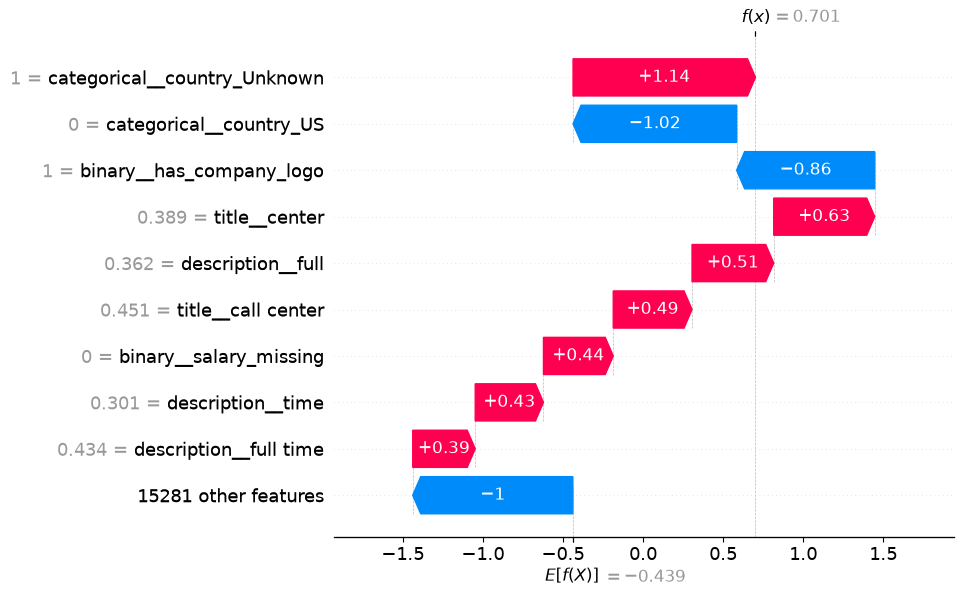


--- Row 54: DATA ENTRY ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.831)


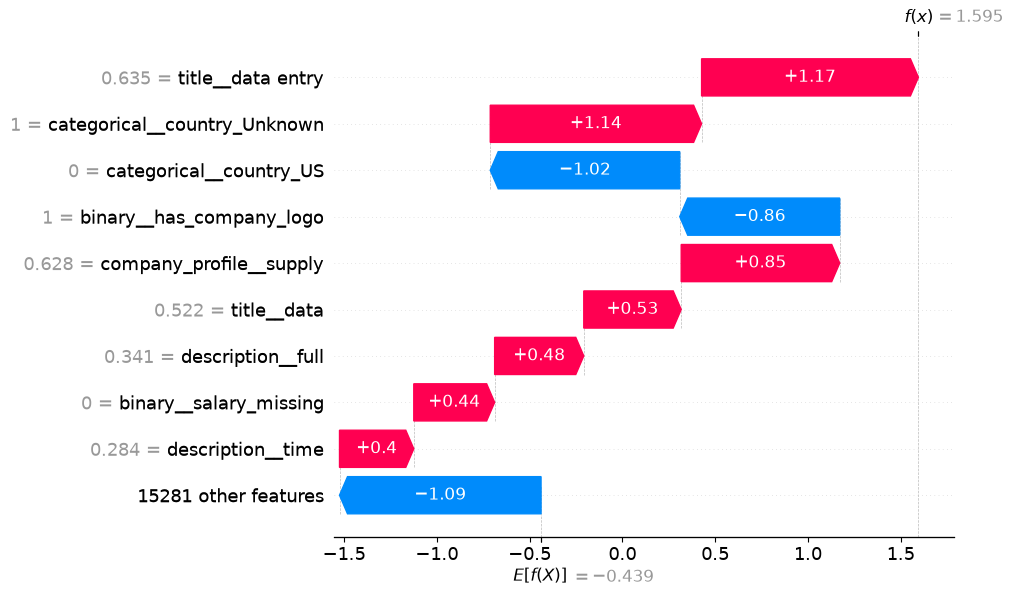


--- Row 73: HR Shared Services Administrative Assistant ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.700)


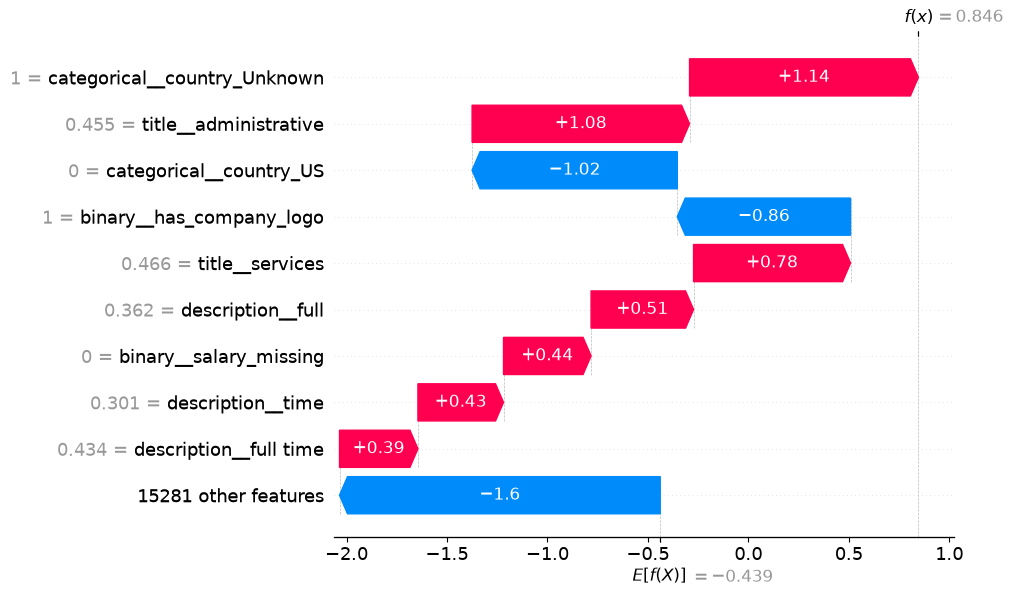


--- Row 77: Remote Call Center Sales Agent ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.765)


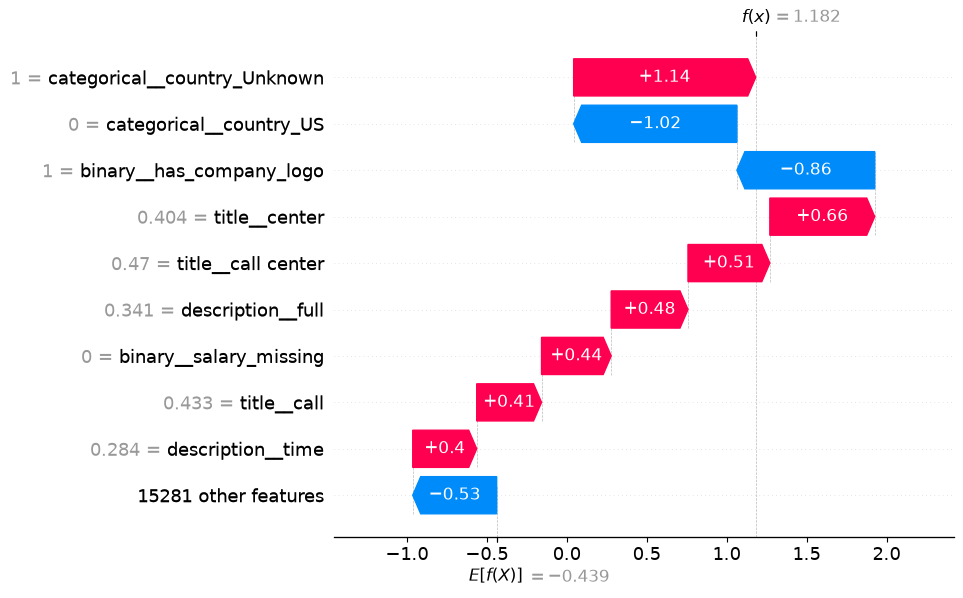


--- Row 50: Remote Insurance Call Center Support ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.669)


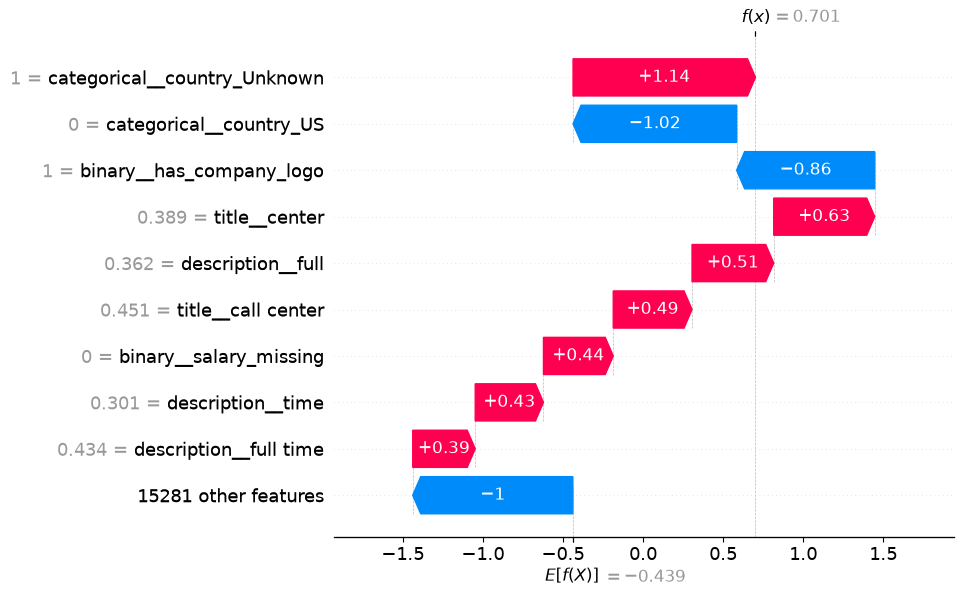


--- Row 54: DATA ENTRY ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.831)


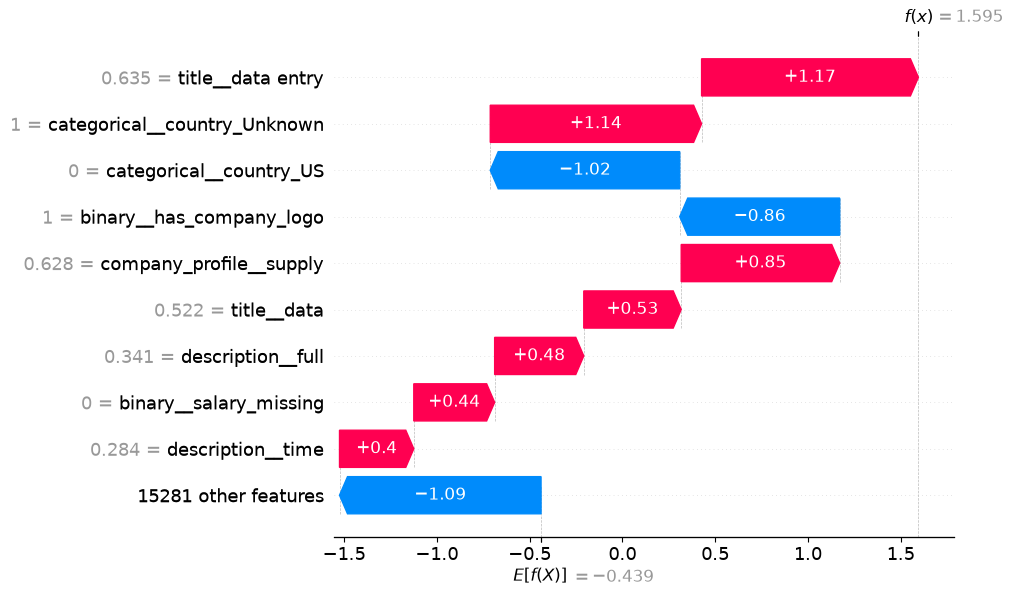


--- Row 73: HR Shared Services Administrative Assistant ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.700)


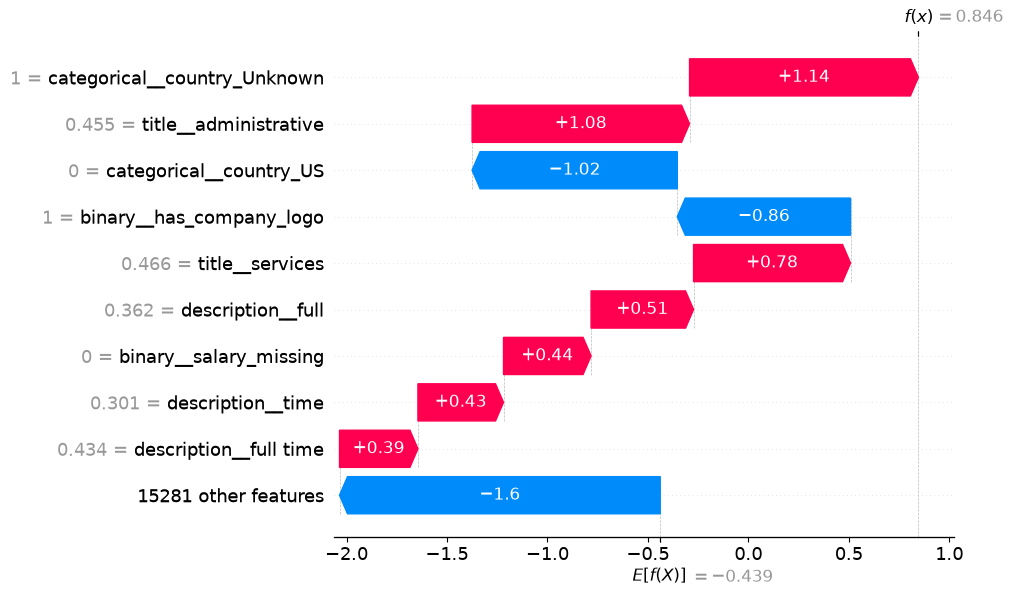


--- Row 77: Remote Call Center Sales Agent ---
Actual: Real | Predicted: Fraudulent (fraud probability: 0.765)


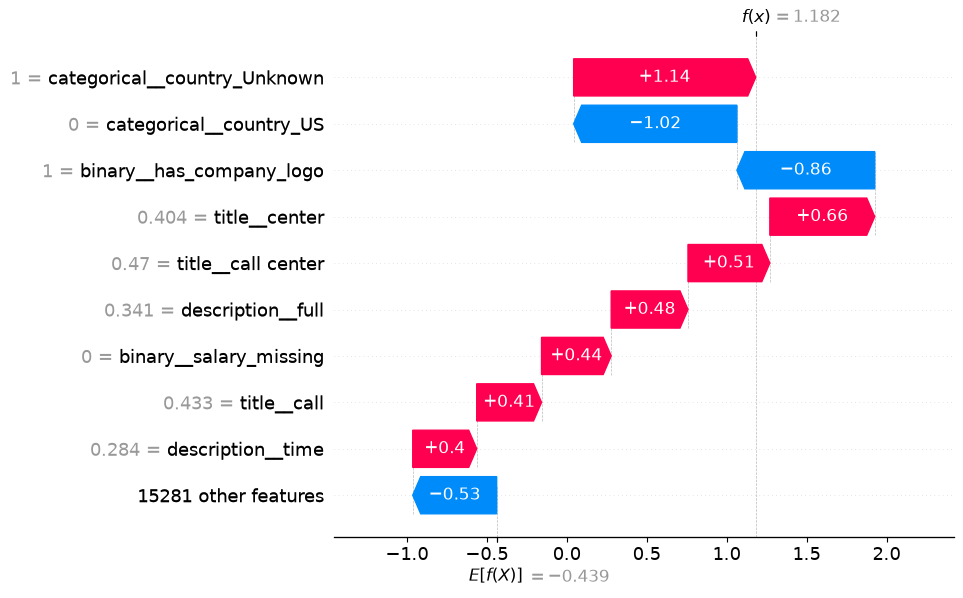

In [26]:
feature_names = joblib.load("../models/feature_names.joblib")

# Recreate the explanation with proper feature names attached
shap_values_holdout = shap.Explanation(
    values=shap_values_holdout.values,
    base_values=shap_values_holdout.base_values,
    data=shap_values_holdout.data,
    feature_names=feature_names
)
fp_indices = df.index[(y_true == 0) & (pd.Series(y_pred) == 1)].tolist()

for idx in fp_indices:
    pred_label = "Fraudulent" if y_pred[idx] == 1 else "Real"
    pred_proba = y_proba[idx]
    
    print(f"\n--- Row {idx}: {df.loc[idx, 'title']} ---")
    print(f"Actual: Real | Predicted: {pred_label} (fraud probability: {pred_proba:.3f})")
    
    shap.plots.waterfall(shap_values_holdout[idx], max_display=10)
def show_prediction(idx):
    actual_label = "Fraudulent" if y_true[idx] == 1 else "Real"
    pred_label = "Fraudulent" if y_pred[idx] == 1 else "Real"
    pred_proba = y_proba[idx]
    
    print(f"\n--- Row {idx}: {df.loc[idx, 'title']} ---")
    print(f"Actual: {actual_label} | Predicted: {pred_label} (fraud probability: {pred_proba:.3f})")
    
    shap.plots.waterfall(shap_values_holdout[idx], max_display=10)

# Example usage
for idx in fp_indices:
    show_prediction(idx)

In [27]:
import pandas as pd
import numpy as np

fp_indices = df.index[(y_true == 0) & (pd.Series(y_pred) == 1)].tolist()

# Make a copy so we don't disturb your original holdout
df_test = df.loc[fp_indices].copy()

# Original predictions (already have these, but let's pull them together for the comparison)
original_proba = y_proba[fp_indices]

# Now flip country from 'Unknown' to a plausible real value for a remote US-based posting
df_test['country'] = 'US'  # or whatever value appears most frequently in EMSCAD's real class

# Rerun through the SAME preprocessor (transform only)
X_test_variant = preprocessor.transform(df_test)

# Get new probabilities
new_proba = model.predict_proba(X_test_variant)[:, 1]
new_pred = model.predict(X_test_variant)

# Compare side by side
comparison = pd.DataFrame({
    'title': df_test['title'].values,
    'original_proba': original_proba,
    'original_pred': ['Fraudulent' if p == 1 else 'Real' for p in y_pred[fp_indices]],
    'new_proba (country=US)': new_proba,
    'new_pred (country=US)': ['Fraudulent' if p == 1 else 'Real' for p in new_pred]
})

print(comparison.to_string(index=False))

                                      title  original_proba original_pred  new_proba (country=US) new_pred (country=US)
       Remote Insurance Call Center Support        0.668517    Fraudulent                0.740108            Fraudulent
                                 DATA ENTRY        0.831309    Fraudulent                0.874350            Fraudulent
HR Shared Services Administrative Assistant        0.699732    Fraudulent                0.766932            Fraudulent
             Remote Call Center Sales Agent        0.765283    Fraudulent                0.821554            Fraudulent


In [28]:
raw = pd.read_csv("../data/processed/emscad_cleaned.csv")
print(pd.crosstab(raw['country'] == 'Unknown', raw['fraudulent'], normalize='index'))


fraudulent         0         1
country                       
False       0.951694  0.048306
True        0.945087  0.054913


In [29]:
tp_indices = df.index[(y_true == 1) & (pd.Series(y_pred) == 1)].tolist()

# Split by whether brand impersonation was flagged, to compare fraud "types"
brand_impersonation_tp = [i for i in tp_indices if df.loc[i, 'Brand Impersonation?'].startswith('Yes')]
non_impersonation_tp = [i for i in tp_indices if df.loc[i, 'Brand Impersonation?'] == 'No']

print(f"Brand impersonation TPs: {len(brand_impersonation_tp)}")
print(f"Non-impersonation TPs: {len(non_impersonation_tp)}")

Brand impersonation TPs: 30
Non-impersonation TPs: 5



--- Row 0: Work From Home Data Entry Executive ---
Actual: Fraudulent | Predicted: Fraudulent (fraud probability: 0.998)


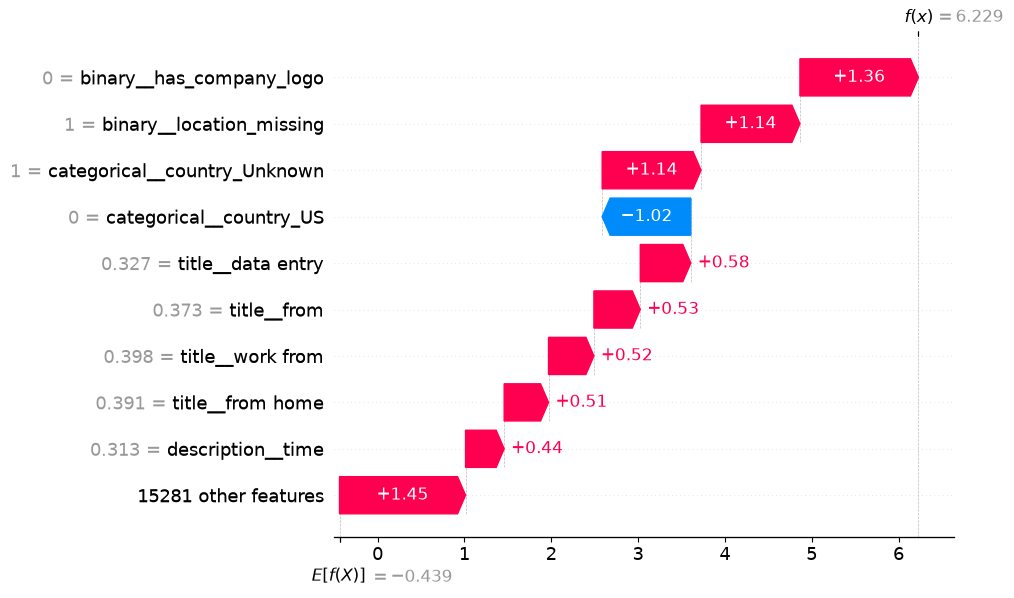


--- Row 1: Online Form Filling Executive ---
Actual: Fraudulent | Predicted: Fraudulent (fraud probability: 0.792)


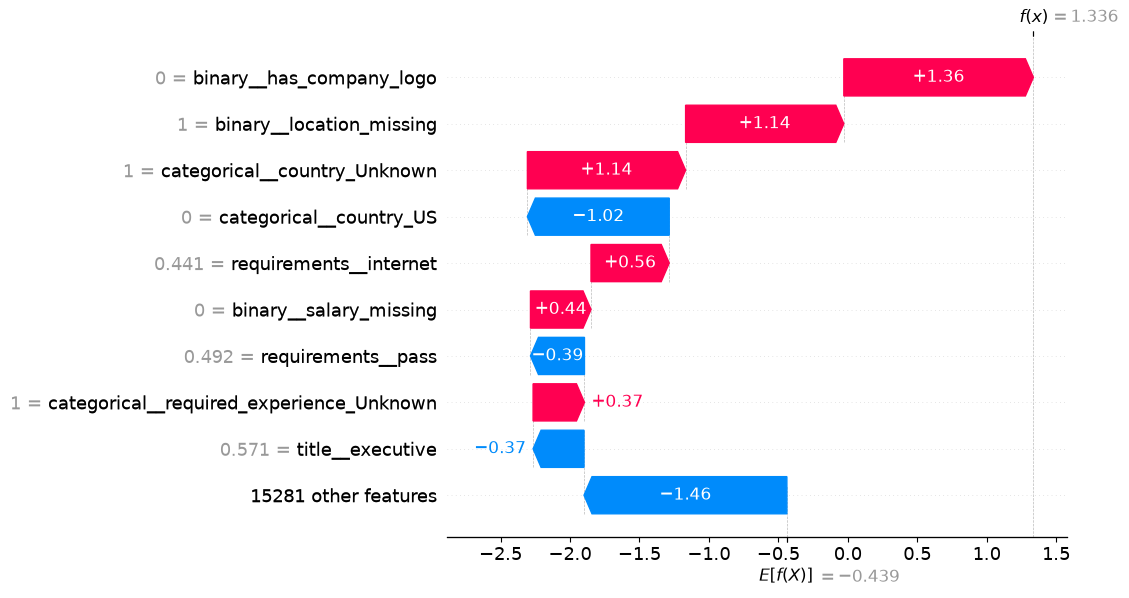


--- Row 9: Work From Home Process Associate ---
Actual: Fraudulent | Predicted: Fraudulent (fraud probability: 0.989)


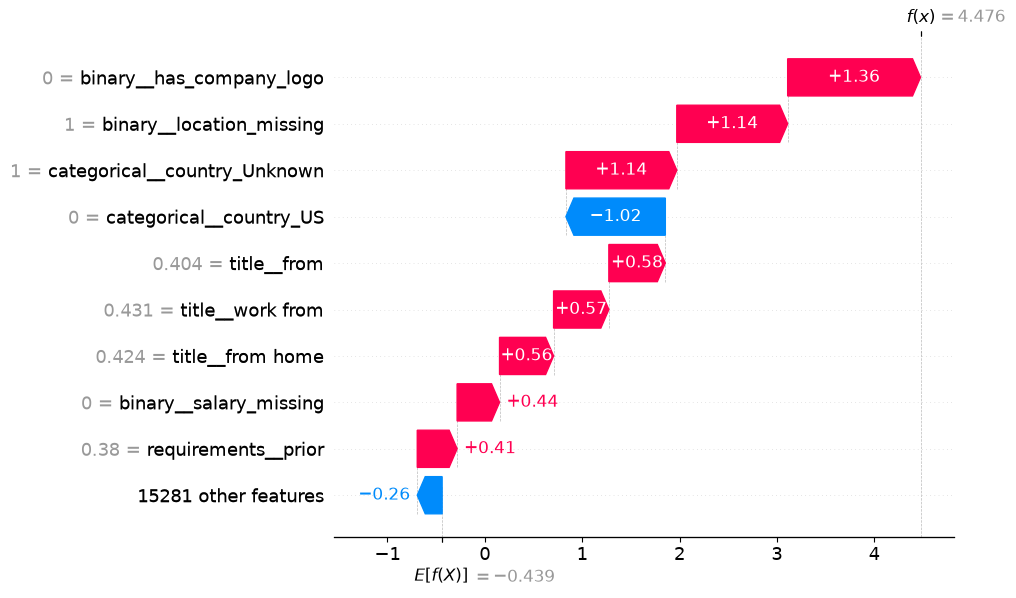


--- Row 19: Chat Support Executive ---
Actual: Fraudulent | Predicted: Fraudulent (fraud probability: 0.767)


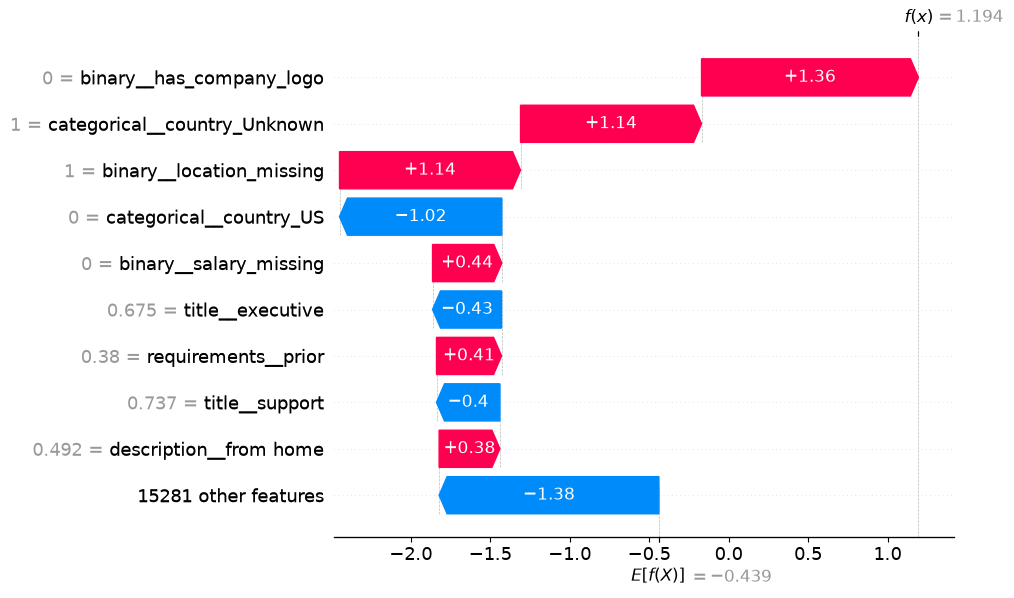

In [30]:
# Pick 2 from each category
sample_tp = brand_impersonation_tp[:2] + non_impersonation_tp[:2]

for idx in sample_tp:
    show_prediction(idx)

In [31]:
import numpy as np

def top_features_for_group(indices, n=10):
    group_shap = shap_values_holdout.values[indices]
    mean_abs = np.abs(group_shap).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-n:][::-1]
    return [(feature_names[i], round(mean_abs[i], 3)) for i in top_idx]

print("Top features — Brand impersonation fraud:")
print(top_features_for_group(brand_impersonation_tp))

print("\nTop features — Non-impersonation (MLM/target-based) fraud:")
print(top_features_for_group(non_impersonation_tp))

Top features — Brand impersonation fraud:
[('binary__has_company_logo', np.float64(1.365)), ('categorical__country_Unknown', np.float64(1.139)), ('binary__location_missing', np.float64(1.139)), ('categorical__country_US', np.float64(1.021)), ('binary__salary_missing', np.float64(0.436)), ('categorical__required_experience_Unknown', np.float64(0.37)), ('binary__telecommuting', np.float64(0.29)), ('requirements__pass', np.float64(0.258)), ('categorical__industry_Oil & Energy', np.float64(0.242)), ('title__executive', np.float64(0.242))]

Top features — Non-impersonation (MLM/target-based) fraud:
[('binary__has_company_logo', np.float64(1.365)), ('categorical__country_Unknown', np.float64(1.139)), ('binary__location_missing', np.float64(1.139)), ('categorical__country_US', np.float64(1.021)), ('binary__salary_missing', np.float64(0.436)), ('categorical__required_experience_Unknown', np.float64(0.37)), ('description__from home', np.float64(0.309)), ('binary__telecommuting', np.float64(0.29

In [32]:
# Get only text-based feature indices (title, company_profile, description, requirements, benefits)
text_feature_mask = [not (f.startswith('binary__') or f.startswith('categorical__')) 
                      for f in feature_names]
text_feature_idx = np.where(text_feature_mask)[0]

def top_text_features_for_group(indices, n=10):
    group_shap = shap_values_holdout.values[indices][:, text_feature_idx]
    mean_abs = np.abs(group_shap).mean(axis=0)
    top_local_idx = np.argsort(mean_abs)[-n:][::-1]
    global_idx = text_feature_idx[top_local_idx]
    return [(feature_names[i], round(mean_abs[i], 3)) for i in [text_feature_idx[j] for j in top_local_idx]]

print("Top TEXT features — Brand impersonation fraud:")
print(top_text_features_for_group(brand_impersonation_tp))

print("\nTop TEXT features — Non-impersonation (MLM/target-based) fraud:")
print(top_text_features_for_group(non_impersonation_tp))

Top TEXT features — Brand impersonation fraud:
[('requirements__pass', np.float64(0.258)), ('title__executive', np.float64(0.242)), ('description__from home', np.float64(0.23)), ('description__time', np.float64(0.203)), ('title__data entry', np.float64(0.196)), ('title__data', np.float64(0.136)), ('description__work from', np.float64(0.132)), ('description__hours', np.float64(0.127)), ('description__from', np.float64(0.127)), ('requirements__internet', np.float64(0.126))]

Top TEXT features — Non-impersonation (MLM/target-based) fraud:
[('description__from home', np.float64(0.309)), ('requirements__prior', np.float64(0.248)), ('title__executive', np.float64(0.219)), ('description__from', np.float64(0.193)), ('requirements__pass', np.float64(0.18)), ('description__work from', np.float64(0.176)), ('company_profile__private', np.float64(0.148)), ('requirements__experience required', np.float64(0.14)), ('requirements__no', np.float64(0.137)), ('title__from', np.float64(0.132))]


In [33]:
from scipy import sparse
import numpy as np, joblib

X_train_resampled = sparse.load_npz("../data/processed/X_train_resampled.npz")
rng = np.random.RandomState(42)
idx = rng.choice(X_train_resampled.shape[0], size=100, replace=False)
joblib.dump(X_train_resampled[idx], "../models/shap_background.joblib")

['../models/shap_background.joblib']

In [ ]:
python test_analyzer.py


SyntaxError: invalid syntax (932903499.py, line 1)